Create a binary variable, mpg01, that contains a 1 if mpg contains
a value above its median, and a 0 if mpg contains a value below
its median. You can compute the median using the median()
method of the data frame. Note you may find it helpful to add
a column mpg01 to the data frame by assignment. Assuming you
have stored the data frame as Auto, this can be done as follows:

In [56]:
from ISLP import load_data
import pandas as pd
import seaborn as sns

auto = load_data("Auto")

In [57]:
auto["mpg01"] = auto["mpg"] > auto["mpg"].mean()
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,False
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,False
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,False
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,False
ford torino,17.0,8,302.0,140,3449,10.5,70,1,False


Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other
features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

In [58]:
auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209,0.840822
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,-0.734037
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,-0.735585
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.649491
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,-0.744503
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746,0.320970
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528,0.451010
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000,0.519228
mpg01,0.840822,-0.734037,-0.735585,-0.649491,-0.744503,0.320970,0.451010,0.519228,1.000000


<Axes: >

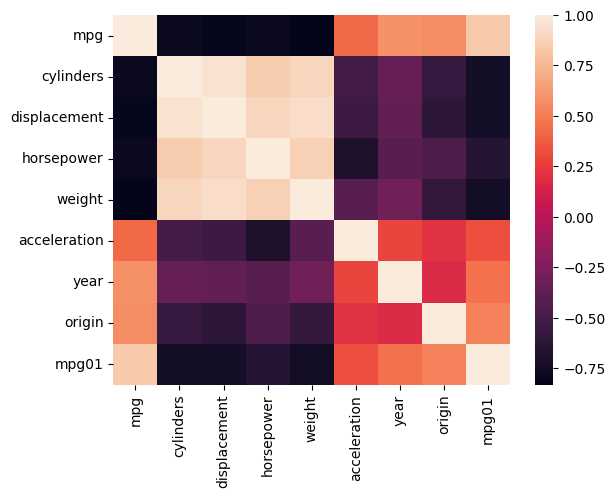

In [59]:
sns.heatmap(auto.corr())

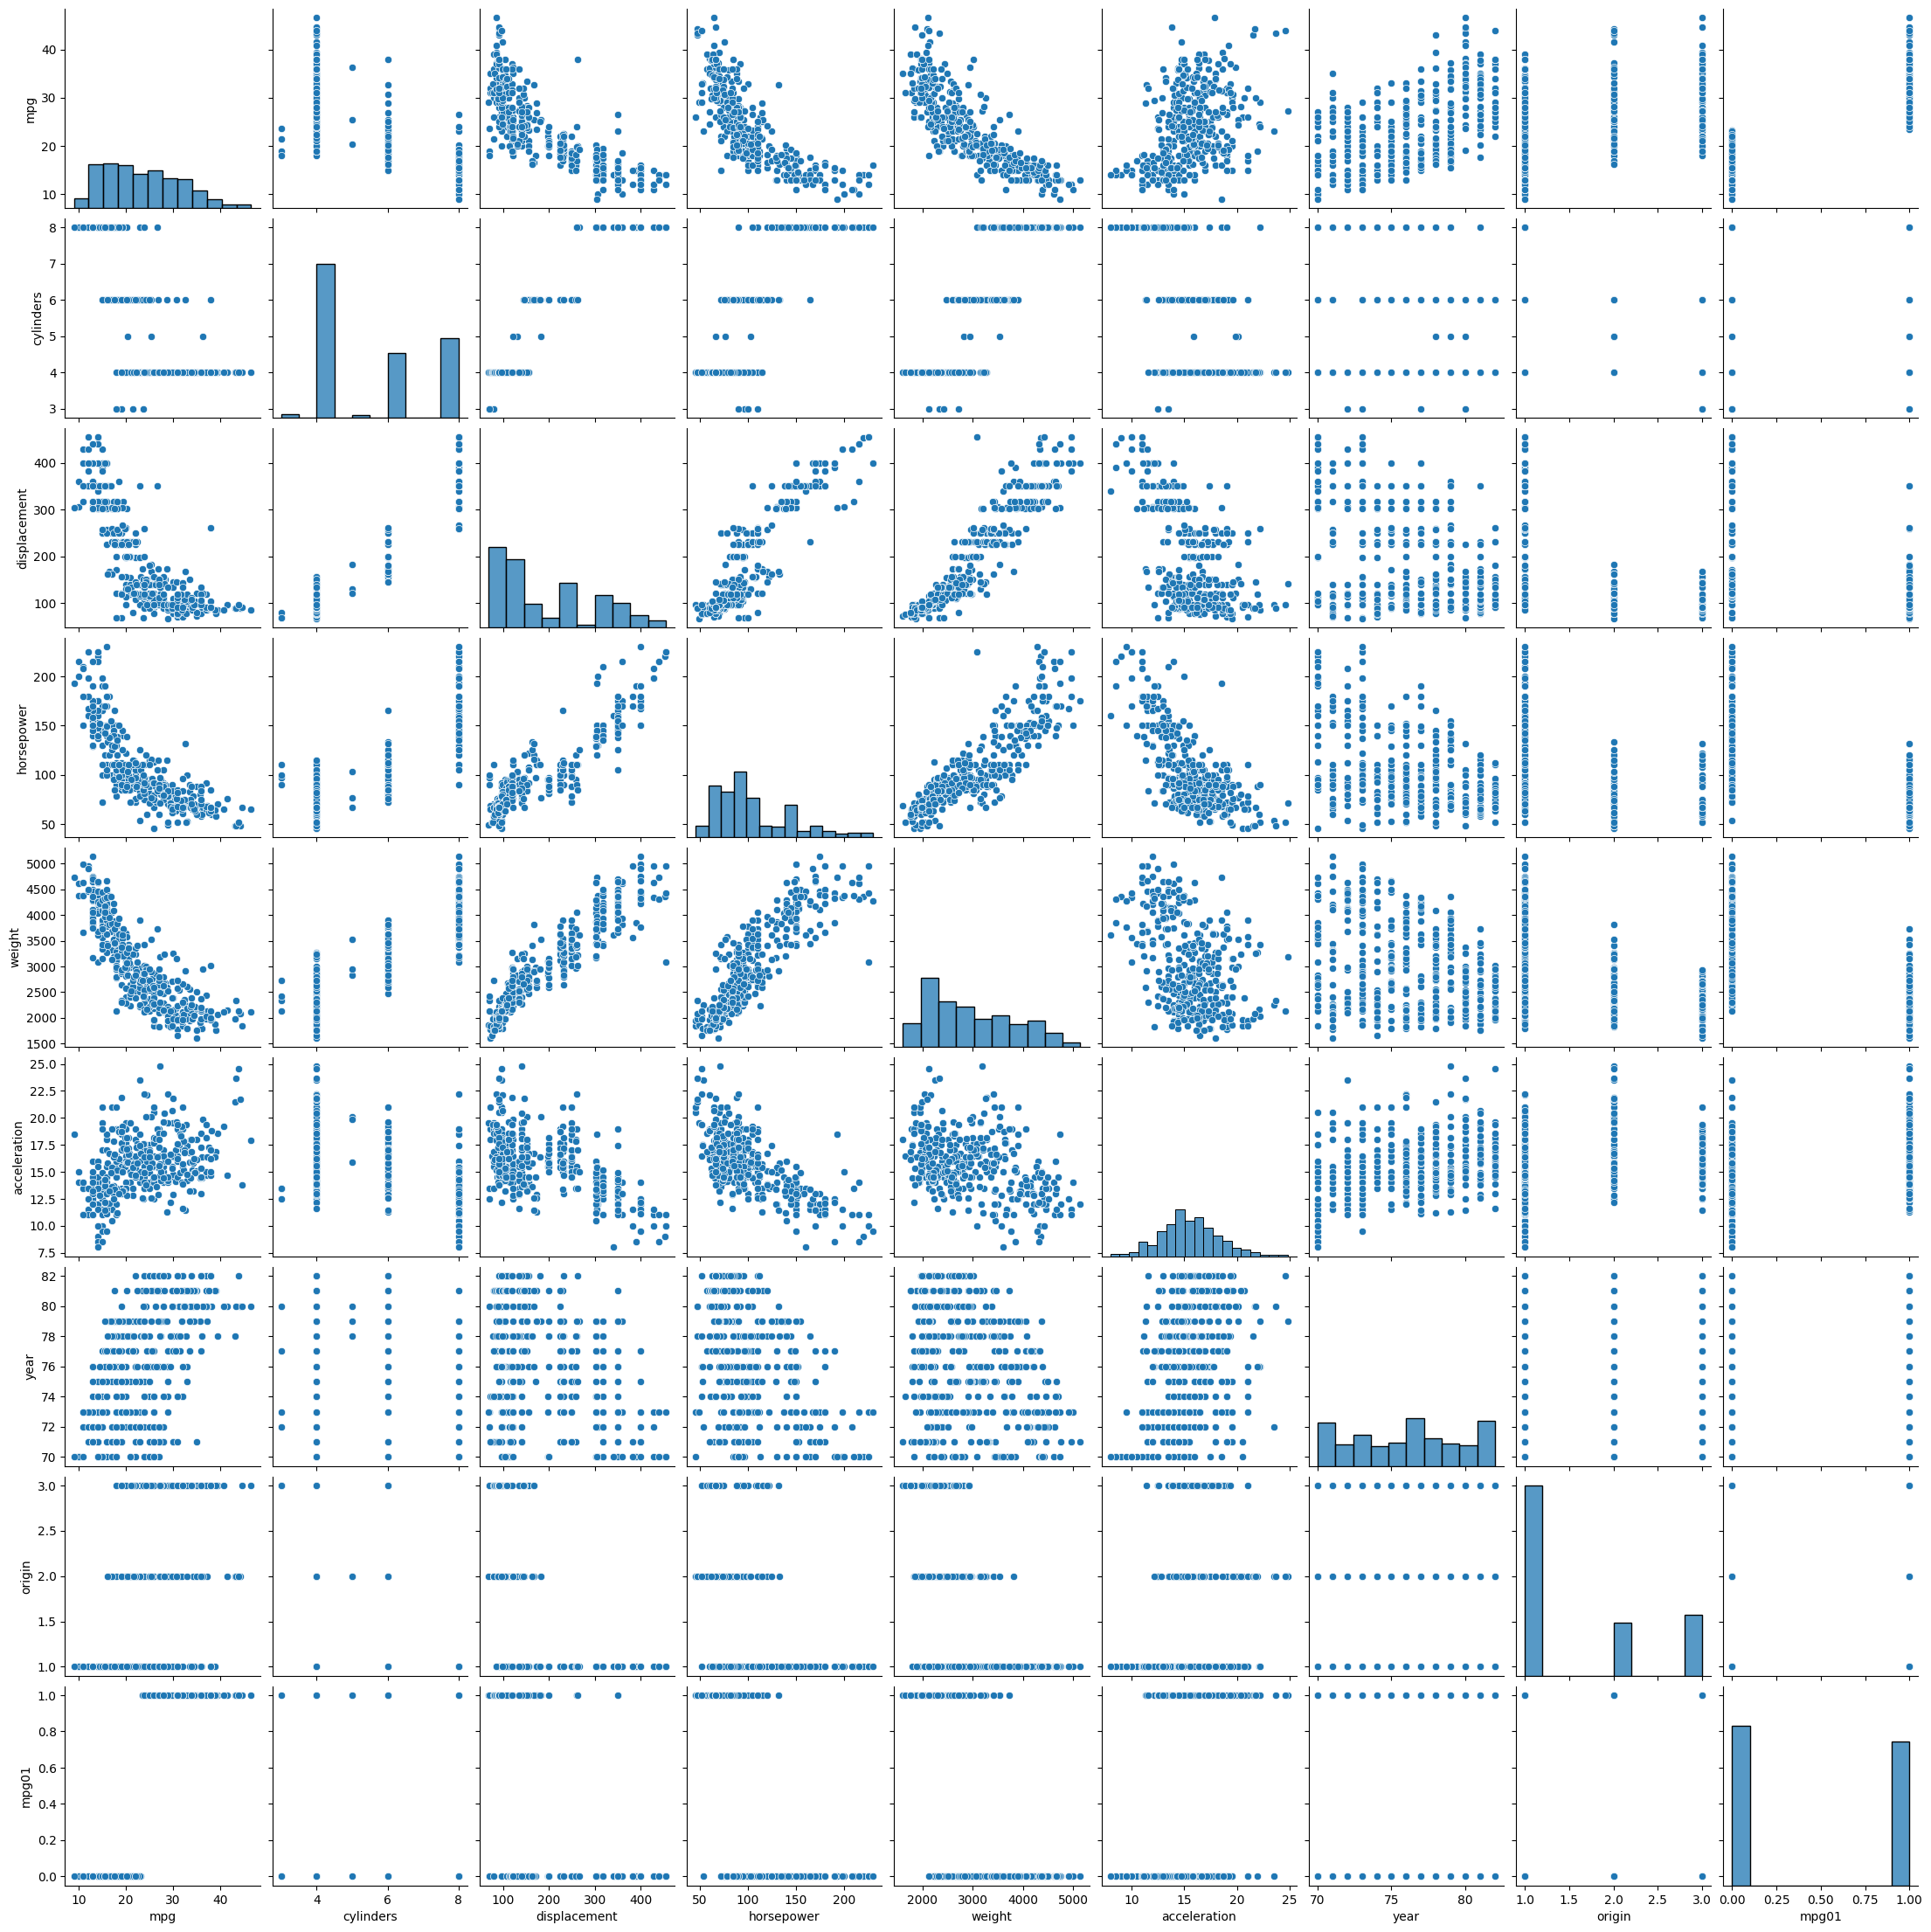

In [60]:
sns.pairplot(auto)

+ displacement
+ weight
+ acceleration
+ horse power

 Split the data into a training set and a test set.

In [61]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(auto)

 Perform LDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

In [62]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

features = ["displacement", "weight", "acceleration", "horsepower"]

X_train = train[features]
X_test = test[features]
y_train = train["mpg01"]
y_test = test["mpg01"]

lda = LDA(store_covariance=True)
lda.fit(X_train, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,True
,tol,0.0001
,covariance_estimator,None


In [63]:
labels = lda.predict(X_test)
display(labels[:5])

import numpy as np
np.mean(labels == y_test)

array([False, False, False, False, False])

np.float64(0.8775510204081632)

 Perform QDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

In [64]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

qda = QDA()
qda.fit(X_train, y_train)

,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


In [65]:
labels = qda.predict(X_test)
np.mean(labels == y_test)

np.float64(0.9285714285714286)

Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with
mpg01 in (b). What is the test error of the model obtained?

In [66]:
from ISLP.models import (ModelSpec as MS,
summarize)
import statsmodels.api as sm

design = MS(features)
X = design.fit_transform(X_train)
X_dtest = design.transform(X_test)

In [67]:
glm = sm.GLM(y_train,X,family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,13.7437,3.029,4.537,0.000
displacement,-0.0114,0.007,-1.730,0.084
weight,-0.0013,0.001,-1.325,0.185
acceleration,-0.1681,0.138,-1.221,0.222
horsepower,-0.0579,0.022,-2.614,0.009


In [68]:
probs = results.predict(exog=X_dtest)
labels = probs > 0.5
np.mean(labels == y_test)

np.float64(0.9081632653061225)

Perform naive Bayes on the training data in order to predict
mpg01 using the variables that seemed most associated with mpg01
in (b). What is the test error of the model obtained?

In [69]:
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
summarize)
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [70]:
NB = GaussianNB()
NB.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [71]:
labels = NB.predict(X_test)

table = confusion_table(labels, y_test)
display(table)
display(np.mean(labels == y_test), np.mean(labels != y_test))

Truth,False,True
Predicted,,
False,47,0
True,10,41


np.float64(0.8979591836734694)

np.float64(0.10204081632653061)

Perform KNN on the training data, with several values of K, in
order to predict mpg01. Use only the variables that seemed most
associated with mpg01 in (b). What test errors do you obtain?
Which value of K seems to perform the best on this data set?

In [72]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [73]:
labels = knn.predict(X_test)

table = confusion_table(labels, y_test)
display(table)
display(np.mean(labels == y_test), np.mean(labels != y_test))

Truth,False,True
Predicted,,
False,50,5
True,7,36


np.float64(0.8775510204081632)

np.float64(0.12244897959183673)